In [23]:
import pandas as pd
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('telco.csv')

In [5]:
df.head()

,ID,region,tenure,age,marital,address,income,ed,retire,gender,voice,internet,forward,custcat,churn
0,1,Zone 2,13,44,Married,9,64,College degree,No,Male,No,No,Yes,Basic service,Yes
1,2,Zone 3,11,33,Married,7,136,Post-undergraduate degree,No,Male,Yes,No,Yes,Total service,Yes
2,3,Zone 3,68,52,Married,24,116,Did not complete high school,No,Female,No,No,No,Plus service,No
3,4,Zone 2,33,33,Unmarried,12,33,High school degree,No,Female,No,No,No,Basic service,Yes
4,5,Zone 2,23,30,Married,9,30,Did not complete high school,No,Male,No,No,Yes,Plus service,No


In [12]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)

df_encoded = pd.get_dummies(df.drop(columns=['tenure', 'churn']), drop_first=True)

df_encoded['duration'] = df['duration']
df_encoded['event'] = df['event']

if df_encoded['event'].dtype != 'int':
    df_encoded['event'] = df_encoded['event'].map({'Yes': 1, 'No': 0})


# Weibull AFT

In [18]:
weibull_aft = WeibullAFTFitter()
weibull_aft.fit(df_encoded, duration_col='duration', event_col='event')
print("Weibull AFT model summary:")
print(weibull_aft.summary)

Weibull AFT model summary:
                                              coef     exp(coef)     se(coef)  \
param   covariate                                                               
lambda_ address                           0.005560  1.005575e+00     0.007398   
        age                               0.024207  1.024503e+00     0.005797   
        custcat_E-service                 0.726971  2.068805e+00     0.135433   
        custcat_Plus service              0.385602  1.470499e+00     0.188819   
        custcat_Total service             0.587393  1.799292e+00     0.184311   
        ed_Did not complete high school   0.205516  1.228159e+00     0.167382   
        ed_High school degree             0.089570  1.093704e+00     0.125282   
        ed_Post-undergraduate degree     -0.036417  9.642382e-01     0.160272   
        ed_Some college                   0.032115  1.032636e+00     0.124757   
        event_Yes                       -16.127563  9.905776e-08  2164.628691   
 

# Log-Normal AFT

In [21]:
lognormal_aft = LogNormalAFTFitter()
lognormal_aft.fit(df_encoded, duration_col='duration', event_col='event')
lognormal_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1086.68
         time fit was run = 2025-05-01 15:44:42 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
mu_    address                          0.02      1.02      0.01           -0.00            0.03                1.00                1.03
       age                              0.02      1.02      0.01            0.01            0.04                1.01                1.04
       custcat_E-service                0.90      2.46      0.16            0.59            1.21                1.81                3.34
       custcat_Plus service             0.56      1.75      0.23            0.12            1.00                1.13                2.73
       custcat_Total service            0.79      2.21      0.23            0.35            1.24                1.42                3.45
       ed_Did not complete high school -0.07      0.94      0.20           -0.46            0.33                0.63                1.39
       ed_High school degree            0.03      1.03      0.15           -0.27            0.33                0.77                1.39
       ed_Post-undergraduate degree    -0.13      0.88      0.19           -0.50            0.24                0.61                1.27
       ed_Some college                  0.08      1.09      0.15           -0.21            0.38                0.81                1.47
       event_Yes                       -6.53      0.00    121.73         -245.13          232.06                0.00           6.08e+100
       forward_Yes                     -0.03      0.97      0.18           -0.39            0.32                0.68                1.37
       gender_Male                      0.09      1.09      0.11           -0.12            0.30                0.88                1.35
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.22      0.80      0.13           -0.47            0.03                0.62                1.03
       marital_Unmarried               -0.49      0.62      0.11           -0.70           -0.28                0.50                0.76
       region_Zone 2                    0.00      1.00      0.13           -0.26            0.27                0.77                1.30
       region_Zone 3                   -0.10      0.91      0.13           -0.36            0.17                0.70                1.18
       retire_Yes                      -0.64      0.53      0.56           -1.73            0.45                0.18                1.56
       voice_Yes                       -0.09      0.91      0.15           -0.39            0.21                0.68                1.23
       Intercept                        8.08   3235.94    121.74         -230.51          246.68                0.00           1.35e+107
sigma_ Intercept                       -0.15      0.86      0.04           -0.24           -0.07                0.79                0.93

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
mu_    address                            0.00  1.81   0.07      3.84
       age                                0.00  3.45 <0.005     10.82
       custcat_E-service                  0.00  5.76 <0.005     26.83
       custcat_Plus service               0.00  2.48   0.01      6.26
       custcat_Total service              0.00  3.49 <0.005     10.99
       ed_Did not compl

# Log-Logistic AFT

In [22]:
loglogistic_aft = LogLogisticAFTFitter()
loglogistic_aft.fit(df_encoded, duration_col='duration', event_col='event')
loglogistic_aft.print_summary()

<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1087.87
         time fit was run = 2025-05-01 15:44:50 UTC

---
                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                                        
alpha_ address                          0.01      1.01      0.01           -0.00            0.03                1.00                1.03
       age                              0.03      1.03      0.01            0.01            0.04                1.01                1.04
       custcat_E-service                0.97      2.65      0.16            0.67            1.28                1.95                3.59
       custcat_Plus service             0.59      1.80      0.21            0.17            1.01                1.18                2.74
       custcat_Total service            0.92      2.50      0.22            0.48            1.35                1.62                3.87
       ed_Did not complete high school  0.00      1.00      0.22           -0.42            0.43                0.65                1.53
       ed_High school degree            0.08      1.09      0.15           -0.21            0.38                0.81                1.47
       ed_Post-undergraduate degree    -0.12      0.89      0.18           -0.47            0.24                0.62                1.27
       ed_Some college                  0.08      1.09      0.14           -0.20            0.37                0.82                1.44
       event_Yes                       -6.99      0.00     10.35          -27.27           13.28                0.00            5.88e+05
       forward_Yes                     -0.07      0.94      0.17           -0.40            0.26                0.67                1.30
       gender_Male                      0.07      1.07      0.11           -0.14            0.28                0.87                1.32
       income                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
       internet_Yes                    -0.23      0.80      0.13           -0.48            0.03                0.62                1.03
       marital_Unmarried               -0.52      0.59      0.11           -0.73           -0.31                0.48                0.73
       region_Zone 2                    0.08      1.08      0.13           -0.17            0.33                0.84                1.39
       region_Zone 3                   -0.14      0.87      0.14           -0.41            0.12                0.66                1.13
       retire_Yes                      -0.67      0.51      0.54           -1.74            0.40                0.18                1.49
       voice_Yes                       -0.10      0.90      0.15           -0.40            0.19                0.67                1.21
       Intercept                        8.54   5105.82     10.35          -11.75           28.82                0.00            3.29e+12
beta_  Intercept                        0.72      2.06      0.05            0.62            0.82                1.87                2.27

                                        cmp to     z      p  -log2(p)
param  covariate                                                     
alpha_ address                            0.00  1.67   0.09      3.40
       age                                0.00  3.73 <0.005     12.38
       custcat_E-service                  0.00  6.26 <0.005     31.25
       custcat_Plus service               0.00  2.74   0.01      7.33
       custcat_Total service              0.00  4.14 <0.005     14.80
       ed_Did not com

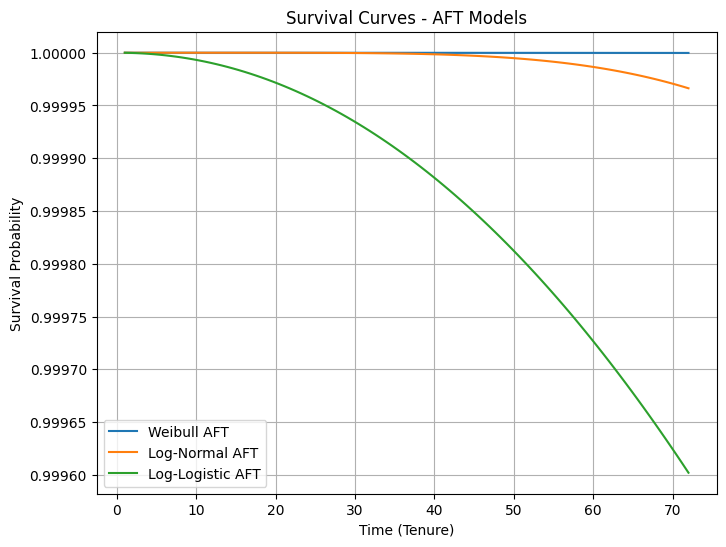

In [25]:
durations = np.linspace(df_encoded['duration'].min(), df_encoded['duration'].max(), 100)
X_ref = df_encoded.drop(columns=['duration', 'event']).mean().to_frame().T
surv_weibull = weibull_aft.predict_survival_function(X_ref, times=durations)
surv_lognormal = lognormal_aft.predict_survival_function(X_ref, times=durations)
surv_loglogistic = loglogistic_aft.predict_survival_function(X_ref, times=durations)

plt.figure(figsize=(8, 6))
plt.plot(durations, surv_weibull.values.flatten(), label='Weibull AFT')
plt.plot(durations, surv_lognormal.values.flatten(), label='Log-Normal AFT')
plt.plot(durations, surv_loglogistic.values.flatten(), label='Log-Logistic AFT')

plt.xlabel('Time (Tenure)')
plt.ylabel('Survival Probability')
plt.title('Survival Curves - AFT Models')
plt.legend()
plt.grid(True)
plt.show()

Based on the log-likelihood and AIC values, the Log-Logistic and Log-Normal models performed similarly and better than the Weibull model. The Weibull model also displayed an almost flat survival curve, which suggests poor flexibility or a potential mismatch with the data distribution. For the Log-Logistic AFT model, key covariates such as age, customer category (custcat_E-service and custcat_Total service), and marital status showed statistically significant effects with p-values well below 0.05. These variables remained significant across both the Log-Logistic and Log-Normal models, strengthening confidence in their relevance. In contrast, the Weibull model coefficients lacked strong significance and did not capture meaningful effects. Considering both the statistical significance of features and the model fit metrics, the Log-Logistic model provides the most interpretable and statistically robust results. Therefore, the Log-Logistic AFT model was selected for further analysis and for retaining only the significant features.

### Which model would I use as a decision maker

After reviewing the models, I would choose the Log-Logistic AFT model. Besides offering a better fit in terms of AIC and significance of key variables, it provides flexibility in modeling changing risk over time, which I believe is important for churn analysis. Unlike the Weibull model that showed almost no variation in survival probability, the Log-Logistic model captured how customer risk evolves with tenure and covariates like age, customer category, and marital status. From a decision-making standpoint, it also makes it easier to explain patterns to stakeholders since the model allows both increasing and decreasing hazard rates, which aligns with how churn risk behaves in real-life customer lifecycles.


In [27]:
significant_features = ['age', 'custcat_E-service', 'custcat_Total service', 'marital_Unmarried']

df_sig = df_encoded[significant_features + ['duration', 'event']]

final_loglogistic = LogLogisticAFTFitter()
final_loglogistic.fit(df_sig, duration_col='duration', event_col='event')

final_loglogistic.print_summary()

<lifelines.LogLogisticAFTFitter: fitted with 1000 total observations, 726 right-censored observations>
             duration col = 'duration'
                event col = 'event'
   number of observations = 1000
number of events observed = 274
           log-likelihood = -1519.17
         time fit was run = 2025-05-01 15:52:43 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                              
alpha_ age                    0.06      1.07      0.01            0.05            0.07                1.05                1.08
       custcat_E-service      0.27      1.31      0.15           -0.02            0.57                0.98                1.77
       custcat_Total service -0.26      0.77      0.14           -0.53            0.01                0.59                1.01
       marital_Unmarried     -0.46      0.63      0.12           -0.69           -0.23                0.50                0.80
       Intercept              2.12      8.34      0.23            1.67            2.57                5.34               13.04
beta_  Intercept              0.23      1.26      0.05            0.13            0.33                1.13                1.39

                              cmp to     z      p  -log2(p)
param  covariate                                           
alpha_ age                      0.00 11.35 <0.005     96.78
       custcat_E-service        0.00  1.80   0.07      3.81
       custcat_Total service    0.00 -1.90   0.06      4.11
       marital_Unmarried        0.00 -3.88 <0.005     13.21
       Intercept                0.00  9.30 <0.005     66.01
beta_  Intercept                0.00  4.40 <0.005     16.52
---
Concordance = 0.73
AIC = 3050.34
log-likelihood ratio test = 172.08 on 4 df
-log2(p) of ll-ratio test = 117.68

# CLV

In [28]:
monthly_revenue = 50

expected_lifetime = final_loglogistic.predict_expectation(df_sig[significant_features])

df_sig['CLV'] = expected_lifetime * monthly_revenue

df_clv = df.copy()
df_clv['CLV'] = df_sig['CLV'].values

df_clv[['age', 'custcat', 'marital', 'CLV']].head()

/var/folders/46/xnv2mlqd3ljcr70pstxc5wgw0000gn/T/ipykernel_17311/1418764697.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sig['CLV'] = expected_lifetime * monthly_revenue


,age,custcat,marital,CLV
0,44,Basic service,Married,28273.372205
1,33,Total service,Married,10844.861990
2,52,Plus service,Married,46900.266805
3,33,Basic service,Unmarried,8902.676002
4,30,Plus service,Married,11660.888174


In [31]:
# customer category
clv_by_custcat = df_clv.groupby('custcat')['CLV'].mean()

# marital status
clv_by_marital = df_clv.groupby('marital')['CLV'].mean()

print("Average CLV by Customer Category:")
print(clv_by_custcat)

print("\nAverage CLV by Marital Status:")
print(clv_by_marital)

# age group
df_clv['age_group'] = pd.cut(df_clv['age'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '60+'])
clv_by_age = df_clv.groupby('age_group')['CLV'].mean()

print("\nAverage CLV by Age Group:")
print(clv_by_age)

Average CLV by Customer Category:
custcat
Basic service    23495.342418
E-service        35608.624127
Plus service     32551.824481
Total service    20283.131816
Name: CLV, dtype: float64

Average CLV by Marital Status:
marital
Married      33014.494720
Unmarried    22907.998851
Name: CLV, dtype: float64

Average CLV by Age Group:
age_group
<30       7403.617186
30-45    16126.170259
45-60    41023.619101
60+      91856.668767
Name: CLV, dtype: float64


/var/folders/46/xnv2mlqd3ljcr70pstxc5wgw0000gn/T/ipykernel_17311/3083273342.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clv_by_age = df_clv.groupby('age_group')['CLV'].mean()


The average CLV varies notably across customer categories, marital statuses, and age groups. Customers using E-service and Plus service categories showed the highest average CLV, with E-service customers having an average CLV of approximately 35,609 and Plus service around 32,552. In contrast, Total service customers exhibited the lowest average CLV at 20,283. When considering marital status, married subscribers had a substantially higher average CLV of about 33,014 compared to unmarried customers, whose average CLV was approximately 22,908.

Age groups also revealed a strong relationship with CLV. Subscribers under 30 had an average CLV of only 7,404, which increased to 16,126 for the 30-45 group and rose sharply to 41,024 for those aged 45-60. The oldest group (60+) had the highest average CLV at 91,857. This pattern highlights that older customers, especially those aged 60 and above, represent the most valuable segment in terms of predicted lifetime and potential revenue.

# Final Report

#### The survival analysis revealed that age, customer category, and marital status significantly affect churn risk. The final Log-Logistic AFT model showed that higher age is associated with longer expected tenure, meaning older subscribers are less likely to churn. Similarly, being in the E-service or Total service categories and being unmarried also influenced survival time. However, married customers and those in the E-service category demonstrated higher customer lifetime value (CLV), indicating they are both less likely to churn and generate more revenue over time. Coefficients from the model confirmed these trends, where age had a positive effect on survival while certain service categories and marital status shaped the hazard function meaningfully.

#### Based on the CLV analysis, the most valuable customer segments are those who are older (particularly age 60+), married, and subscribed to the E-service or Plus service categories. I define valuable customers as those with both a high predicted survival time and a high revenue contribution, meaning they not only stay longer but also provide significant monetary value. Younger customers, especially under 30, showed much lower CLV and higher churn risk.

#### Assuming the dataset reflects the population, I estimate the annual retention budget by considering subscribers at risk of churn within the next year. Using the survival curves, approximately 10-20% of the subscribers fall into a higher-risk category each year. Given the average CLV across valuable segments ranges between $33,000 to $91,000, a retention budget of around 10% of the total at-risk CLV would be reasonable. For example, if 200 subscribers are at risk with an average CLV of $50,000, the budget could be set at $1 million annually to maximize retention ROI.

#### To improve retention, I would recommend focusing personalized offers and loyalty programs on the most valuable segments, especially married and older customers in the E-service category. Additionally, for younger customers with lower CLV, proactive engagement strategies or offering incentives to increase tenure could be considered to gradually shift them into higher-value segments.
